

# Forecasting Petroleum Product Consumption Using Historical Demand Data

- Develop a predictive system to forecast monthly petroleum product consumption (in metric tonnes) using historical consumption data. The system helps energy planners and petroleum companies estimate future fuel demand, enabling better production planning, supply chain optimization, and resource allocation.

## Importing Libraries & Dataset

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv(r"C:\Users\Sarfarazudddin\Downloads\consumption_data.csv")
df.head()

,Month,Year,PRODUCTS,Quantity (000 Metric Tonnes),updated_date
0,August,2023,ATF,676.75,2024-01-03
1,July,2023,ATF,663.23,2024-01-03
2,June,2023,ATF,642.33,2024-01-03
3,May,2023,ATF,670.58,2024-01-03
4,April,2023,ATF,655.98,2024-01-03


## Data Preprocessing

In [ ]:
df.describe()

,Year,Quantity (000 Metric Tonnes)
count,492.000000,492.000000
mean,2021.463415,1453.350244
std,1.039291,1790.256405
min,2020.000000,23.240000
25%,2021.000000,362.070000
50%,2021.000000,858.270000
75%,2022.000000,1967.875000
max,2023.000000,8217.120000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 492 entries, 0 to 491
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Month                         492 non-null    str    
 1   Year                          492 non-null    int64  
 2   PRODUCTS                      492 non-null    str    
 3   Quantity (000 Metric Tonnes)  492 non-null    float64
 4   updated_date                  492 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 30.2 KB


Data contains no null values

In [ ]:
df.shape

(492, 5)

Dataset contains 492 rows and 5 columns.

In [ ]:
# Renaming Columns
df.rename({'Quantity (000 Metric Tonnes)':'Quantity','PRODUCTS':'Products'},axis=1,inplace=True)

removing updated_date column, as it is not useful for us.

In [ ]:
df['updated_date']

0      2024-01-03
1      2024-01-03
2      2024-01-03
3      2024-01-03
4      2024-01-03
          ...    
487    2024-01-03
488    2024-01-03
489    2024-01-03
490    2024-01-03
491    2024-01-03
Name: updated_date, Length: 492, dtype: str

In [ ]:
df.drop(columns=['updated_date'],inplace=True)

#### Validating Column Values

In [ ]:
df["Month"].unique()

<ArrowStringArray>
[   'August',      'July',      'June',       'May',     'April',     'March',
  'February',   'January',  'December',  'November',   'October', 'September']
Length: 12, dtype: str

In [ ]:
# Various products/by-products in production
df["Products"].unique()

<ArrowStringArray>
[                 'ATF',              'Bitumen',            'FO & LSHS',
                  'HSD',                  'LDO',                  'LPG',
 'Lubricants & Greases',                   'MS',              'Naphtha',
               'Others',       'Petroleum coke',                  'SKO']
Length: 12, dtype: str

In [ ]:
df["Year"].unique()

array([2023, 2022, 2021, 2020])

data consists from year 2020 to 2021

## Exploratory Data Analysis(EDA)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

### Average Production per year

<Axes: xlabel='Year', ylabel='Quantity'>

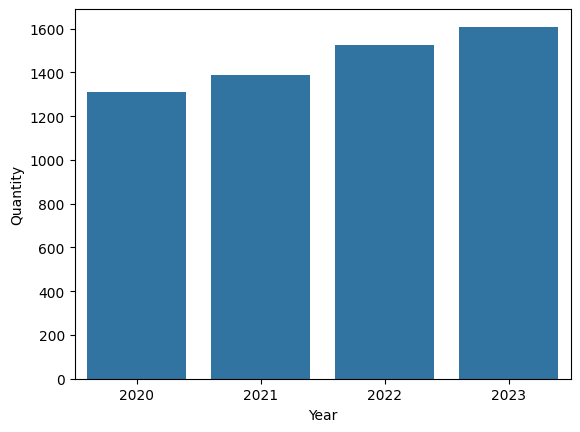

In [ ]:
#Average production per year
avg_prod = df.groupby("Year")["Quantity"].mean()
avg_prod = pd.DataFrame(avg_prod)
sns.barplot(avg_prod,x='Year',y='Quantity')

Inference: Average production of petroleum products are increasing year by year.

### Total Production for each Product(2020-2023)

[Text(0, 0, '19393.9'),
 Text(0, 0, '26891.3'),
 Text(0, 0, '21576.1'),
 Text(0, 0, '272769'),
 Text(0, 0, '2933.25'),
 Text(0, 0, '95899.6'),
 Text(0, 0, '14025.9'),
 Text(0, 0, '109250'),
 Text(0, 0, '45048.9'),
 Text(0, 0, '46845.3'),
 Text(0, 0, '56409.5'),
 Text(0, 0, '4005.79')]

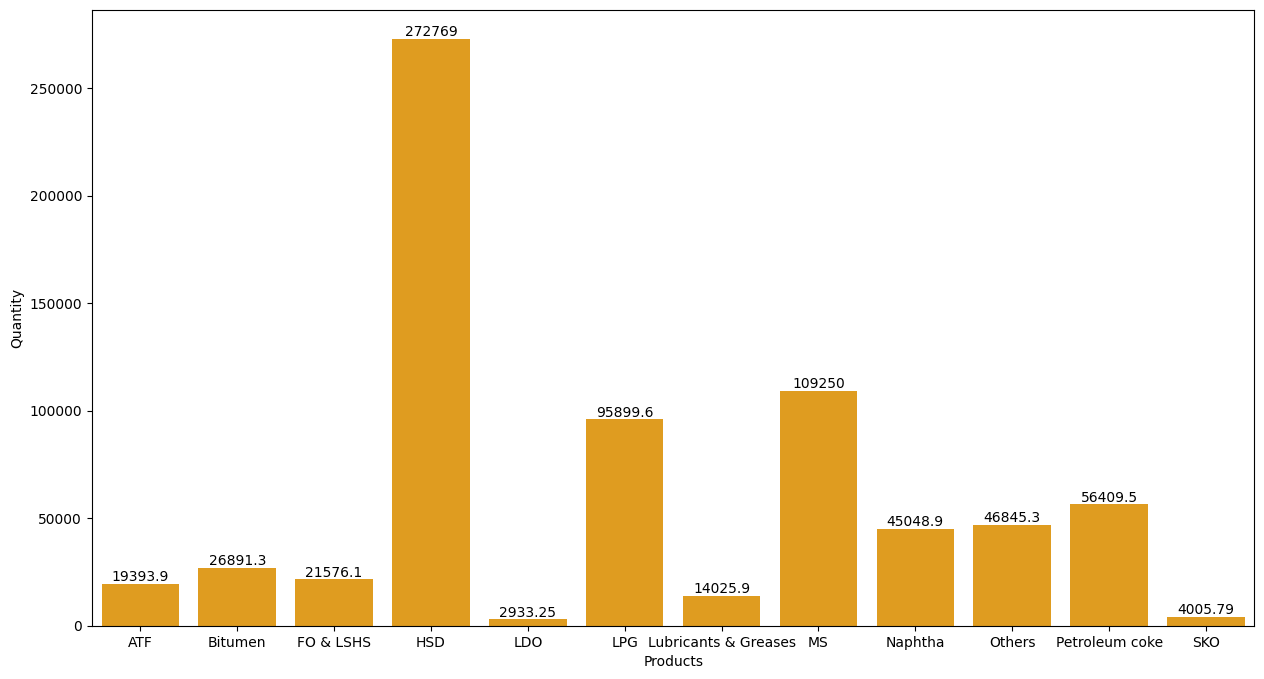

In [ ]:
tot_prod = df.groupby('Products')["Quantity"].sum()
tot_prod = pd.DataFrame(tot_prod)
plt.figure(figsize=(15,8))
ax = sns.barplot(tot_prod,x='Products',y='Quantity',color='orange')
ax.bar_label(ax.containers[0])

High Speed Diesel (HSD) is highest in production(272769 MT).

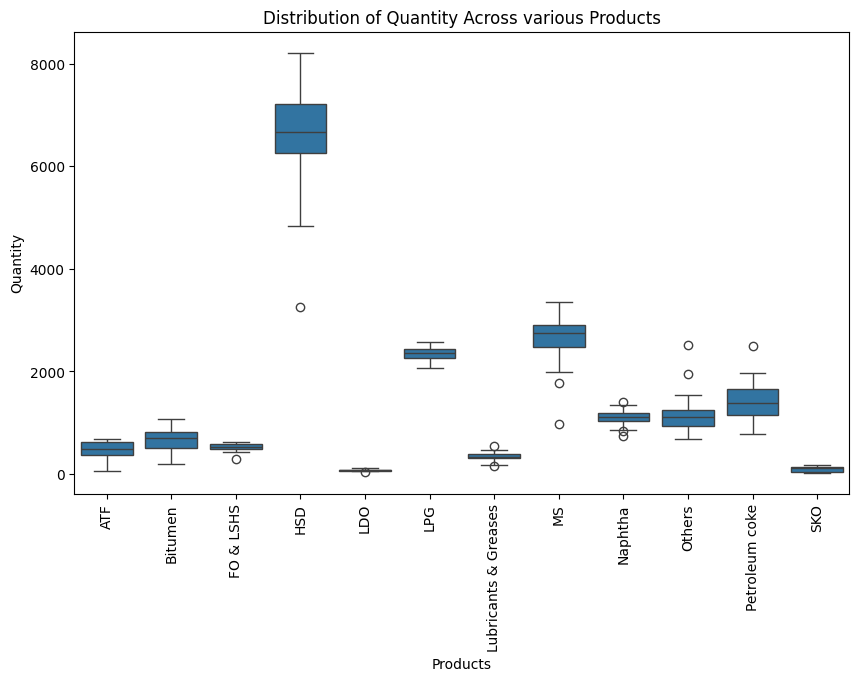

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Products',y='Quantity',data=df)
plt.title("Distribution of Quantity Across various Products")
plt.xticks(rotation=90)
plt.show()

 ## Modeling

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,precision_score

In [ ]:
le = LabelEncoder() #Month
le_1 = LabelEncoder() #Products
df["Month"] = le.fit_transform(df["Month"])
df["Products"] = le_1.fit_transform(df["Products"])

### Outlier Removal

In [ ]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)
IQR = Q3-Q1
outlier = df[((df["Quantity"]<Q1-1.5*IQR)|(df["Quantity"]>Q3+1.5*IQR))]
df.drop(outlier.index,inplace=True)

### Correlation

<Axes: >

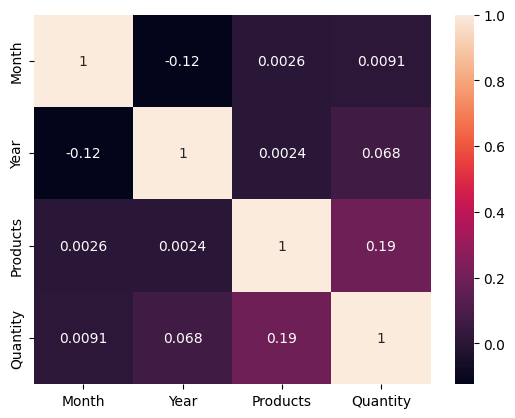

In [ ]:
sns.heatmap(df.corr(),annot=True)

In [ ]:
le.classes_

array(['April', 'August', 'December', 'February', 'January', 'July',
       'June', 'March', 'May', 'November', 'October', 'September'],
      dtype=object)

In [ ]:
le_1.classes_

array(['ATF', 'Bitumen', 'FO & LSHS', 'HSD', 'LDO', 'LPG',
       'Lubricants & Greases', 'MS', 'Naphtha', 'Others',
       'Petroleum coke', 'SKO'], dtype=object)

In [ ]:
df["Products"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [ ]:
df["Month"].unique()

array([ 1,  5,  6,  8,  0,  7,  3,  4,  2,  9, 10, 11])

In [ ]:
x = df.iloc[:,:3]
y = df["Quantity"]
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,shuffle=True,random_state=1)

In [ ]:
#RFR
rfr = RandomForestRegressor(random_state=1,n_estimators=5)
rfr.fit(xtrain,ytrain)
ypred = rfr.predict(xtest)
r2_score(ytest,ypred)

0.9131308963441613

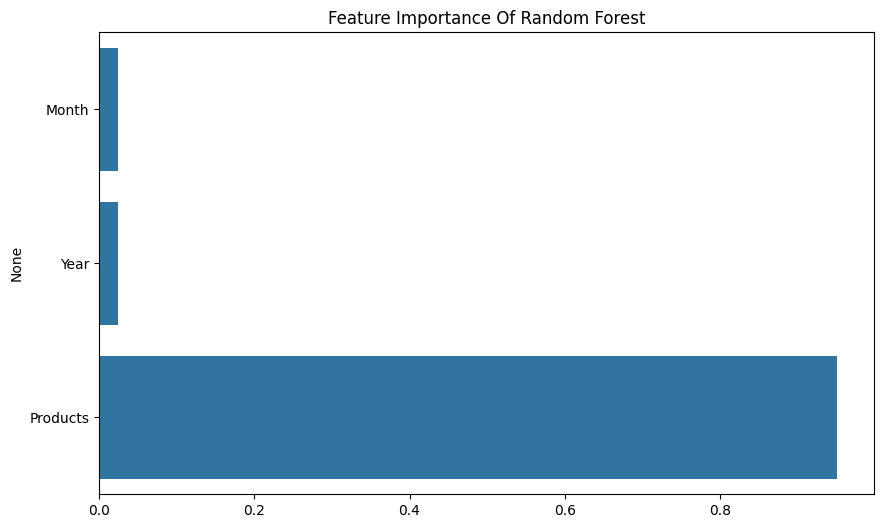

In [ ]:
imp = rfr.feature_importances_
features = x.columns

plt.figure(figsize=(10,6))
sns.barplot(x=imp,y=features)
plt.title("Feature Importance Of Random Forest")
plt.show()

In [ ]:
rfr.score(xtest,ytest)

0.9131308963441613

In [ ]:
rfr.score(xtrain,ytrain)

0.9754354221066412